# DCGAN - CIFAR-10 Image Generation

This project implements a Deep Convolutional Generative Adversarial Network (DCGAN) to generate 32×32 RGB images using CIFAR-10.

The experiment covers adversarial training, convolutional generator and discriminator architectures, generated-image progression, loss dynamics, latent-space interpolation, and qualitative evaluation of generated samples.

GPU: NVIDIA Tesla T4

## 1. Import Required Libraries

Load TensorFlow, NumPy, Matplotlib, and utilities required for GAN training and visualization.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices("GPU")))

if tf.config.list_physical_devices("GPU"):
    print("GPU:", tf.config.list_physical_devices("GPU")[0])

TensorFlow Version: 2.20.0
Num GPUs Available: 1
GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## 2. Configure Reproducibility and Training

Set random seeds and define the latent dimension, image shape, batch size, epochs, and optimizer settings.

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

LATENT_DIM = 100
IMAGE_SIZE = 32
CHANNELS = 3

BATCH_SIZE = 128
EPOCHS = 50

LEARNING_RATE = 0.0002
BETA_1 = 0.5

SAMPLE_COUNT = 16
SAMPLE_INTERVAL = 5

print("Latent Dimension:", LATENT_DIM)
print("Image Shape:", (IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
print("Batch Size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning Rate:", LEARNING_RATE)
print("Beta 1:", BETA_1)

Latent Dimension: 100
Image Shape: (32, 32, 3)
Batch Size: 128
Epochs: 50
Learning Rate: 0.0002
Beta 1: 0.5


## 3. Load the CIFAR-10 Dataset

Load CIFAR-10 images and labels. The labels are retained for dataset inspection; the GAN itself trains without labels.

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training Images:", x_train.shape)
print("Test Images:", x_test.shape)
print("Training Labels:", y_train.shape)
print("Test Labels:", y_test.shape)

cifar10_classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("Classes:", cifar10_classes)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1571s 9us/step
Training Images: (50000, 32, 32, 3)
Test Images: (10000, 32, 32, 3)
Training Labels: (50000, 1)
Test Labels: (10000, 1)
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 4. Explore the Dataset

Inspect the image shape, class distribution, and representative CIFAR-10 images.

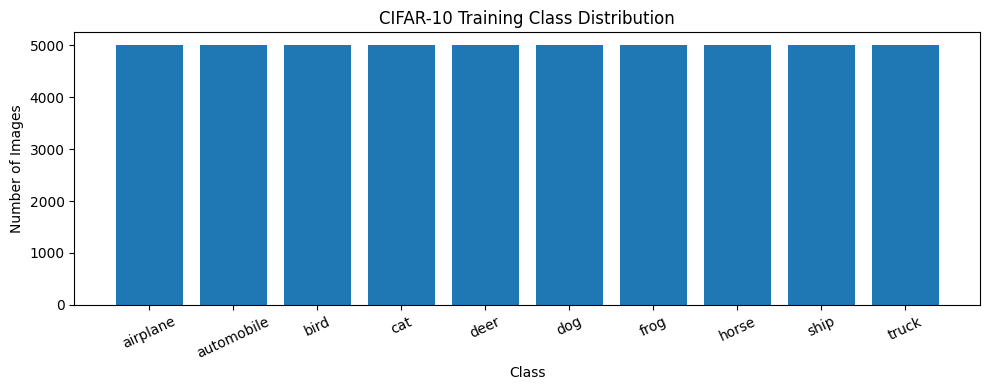

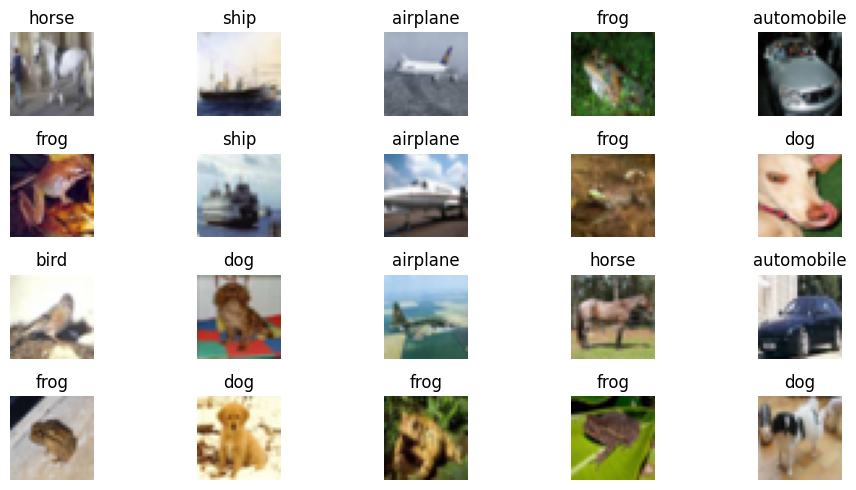

In [4]:
class_counts = np.bincount(
    y_train.flatten(),
    minlength=len(cifar10_classes)
)

plt.figure(figsize=(10, 4))
plt.bar(cifar10_classes, class_counts)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("CIFAR-10 Training Class Distribution")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

sample_indices = np.random.choice(
    len(x_train),
    size=20,
    replace=False
)

for position, index in enumerate(sample_indices):
    ax = plt.subplot(4, 5, position + 1)
    plt.imshow(x_train[index])
    plt.title(cifar10_classes[int(y_train[index][0])])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Preprocess the Images

Normalize image values from [0, 255] to [-1, 1] to match the generator's tanh output.

In [5]:
x_train = (
    x_train.astype("float32") - 127.5
) / 127.5

print("Minimum Pixel Value:", x_train.min())
print("Maximum Pixel Value:", x_train.max())

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(x_train)
    .shuffle(
        buffer_size=len(x_train),
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .batch(
        BATCH_SIZE,
        drop_remainder=True
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)

print("Training batches per epoch:", len(train_dataset))

Minimum Pixel Value: -1.0
Maximum Pixel Value: 1.0
Training batches per epoch: 390


## 6. Build the Generator

Build a convolutional generator that maps random latent vectors to 32×32 RGB images.

In [6]:
def build_generator(latent_dim=LATENT_DIM):
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(latent_dim,)),
            tf.keras.layers.Dense(4 * 4 * 512, use_bias=False),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.LeakyReLU(),
            tf.keras.layers.Reshape((4, 4, 512)),

            tf.keras.layers.Conv2DTranspose(
                256, 4, strides=2, padding="same", use_bias=False
            ),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.LeakyReLU(),

            tf.keras.layers.Conv2DTranspose(
                128, 4, strides=2, padding="same", use_bias=False
            ),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.LeakyReLU(),

            tf.keras.layers.Conv2DTranspose(
                CHANNELS, 4, strides=2, padding="same", activation="tanh"
            )
        ],
        name="generator"
    )
    return model

generator = build_generator()

test_noise = tf.random.normal(
    [1, LATENT_DIM],
    seed=SEED
)

test_generated = generator(
    test_noise,
    training=False
)

print("Generator Output Shape:", test_generated.shape)

Generator Output Shape: (1, 32, 32, 3)


## 7. Build the Discriminator

Build a convolutional discriminator that classifies images as real or generated.

In [7]:
def build_discriminator():
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(
                shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
            ),

            tf.keras.layers.Conv2D(
                64, 4, strides=2, padding="same"
            ),
            tf.keras.layers.LeakyReLU(negative_slope=0.2),
            tf.keras.layers.Dropout(0.3),

            tf.keras.layers.Conv2D(
                128, 4, strides=2, padding="same"
            ),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.LeakyReLU(negative_slope=0.2),
            tf.keras.layers.Dropout(0.3),

            tf.keras.layers.Conv2D(
                256, 4, strides=2, padding="same"
            ),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.LeakyReLU(negative_slope=0.2),
            tf.keras.layers.Dropout(0.3),

            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(1)
        ],
        name="discriminator"
    )
    return model

discriminator = build_discriminator()

test_score = discriminator(
    test_generated,
    training=False
)

print("Discriminator Output Shape:", test_score.shape)

Discriminator Output Shape: (1, 1)


## 8. Inspect the Model Architectures

Print both model summaries and verify generator output and discriminator output shapes.

In [8]:
print("===== GENERATOR =====")
generator.summary()

print("\n===== DISCRIMINATOR =====")
discriminator.summary()

===== GENERATOR =====


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8192)           │       819,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8192)           │        32,768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 256)      │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 3)      │         6,147 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,481,091 (13.28 MB)

 Trainable params: 3,463,939 (13.21 MB)

...

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 664,513 (2.53 MB)

 Trainable params: 663,745 (2.53 MB)

 Non-trainable params: 768 (3.00 KB)

## 9. Define GAN Losses and Optimizers

Define binary cross-entropy losses and separate Adam optimizers for the two adversarial networks.

In [9]:
binary_cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

def discriminator_loss(real_logits, fake_logits):
    real_loss = binary_cross_entropy(
        tf.ones_like(real_logits),
        real_logits
    )
    fake_loss = binary_cross_entropy(
        tf.zeros_like(fake_logits),
        fake_logits
    )
    return real_loss + fake_loss

def generator_loss(fake_logits):
    return binary_cross_entropy(
        tf.ones_like(fake_logits),
        fake_logits
    )

generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    beta_1=BETA_1
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    beta_1=BETA_1
)

print("GAN losses and optimizers are ready.")

GAN losses and optimizers are ready.


## 10. Define the Adversarial Training Step

Implement one generator/discriminator update using TensorFlow gradient tapes.

In [10]:
@tf.function
def train_step(real_images):
    noise = tf.random.normal(
        [BATCH_SIZE, LATENT_DIM]
    )

    with tf.GradientTape() as generator_tape,          tf.GradientTape() as discriminator_tape:

        fake_images = generator(
            noise,
            training=True
        )

        real_logits = discriminator(
            real_images,
            training=True
        )

        fake_logits = discriminator(
            fake_images,
            training=True
        )

        g_loss = generator_loss(
            fake_logits
        )

        d_loss = discriminator_loss(
            real_logits,
            fake_logits
        )

    generator_gradients = generator_tape.gradient(
        g_loss,
        generator.trainable_variables
    )

    discriminator_gradients = discriminator_tape.gradient(
        d_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            generator_gradients,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            discriminator_gradients,
            discriminator.trainable_variables
        )
    )

    return g_loss, d_loss

fixed_noise = tf.random.normal(
    [SAMPLE_COUNT, LATENT_DIM],
    seed=SEED
)

print("Adversarial training step is ready.")

Adversarial training step is ready.


## 11. Train the DCGAN

Train the adversarial system and periodically save generated samples from fixed latent vectors.

In [11]:
progress_epochs = []
progress_images = []
generator_losses = []
discriminator_losses = []

for epoch in range(1, EPOCHS + 1):
    epoch_generator_losses = []
    epoch_discriminator_losses = []

    for real_images in train_dataset:
        g_loss, d_loss = train_step(real_images)

        epoch_generator_losses.append(
            float(g_loss)
        )
        epoch_discriminator_losses.append(
            float(d_loss)
        )

    mean_g_loss = np.mean(
        epoch_generator_losses
    )
    mean_d_loss = np.mean(
        epoch_discriminator_losses
    )

    generator_losses.append(
        mean_g_loss
    )
    discriminator_losses.append(
        mean_d_loss
    )

    if (
        epoch == 1
        or epoch % SAMPLE_INTERVAL == 0
        or epoch == EPOCHS
    ):
        generated_images = generator(
            fixed_noise,
            training=False
        ).numpy()

        progress_epochs.append(epoch)
        progress_images.append(
            generated_images
        )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Generator Loss: {mean_g_loss:.4f} | "
        f"Discriminator Loss: {mean_d_loss:.4f}"
    )

print("Training completed.")

Epoch 01/50 | Generator Loss: 2.0611 | Discriminator Loss: 0.7016
Epoch 02/50 | Generator Loss: 1.5895 | Discriminator Loss: 0.9208
Epoch 03/50 | Generator Loss: 1.5581 | Discriminator Loss: 0.8790
Epoch 04/50 | Generator Loss: 1.5478 | Discriminator Loss: 0.9002
Epoch 05/50 | Generator Loss: 1.8506 | Discriminator Loss: 0.7163
Epoch 06/50 | Generator Loss: 1.8789 | Discriminator Loss: 0.7406
Epoch 07/50 | Generator Loss: 1.9885 | Discriminator Loss: 0.6863
Epoch 08/50 | Generator Loss: 2.1646 | Discriminator Loss: 0.6483
Epoch 09/50 | Generator Loss: 2.2286 | Discriminator Loss: 0.6251
Epoch 10/50 | Generator Loss: 2.2250 | Discriminator Loss: 0.6409
Epoch 11/50 | Generator Loss: 2.2401 | Discriminator Loss: 0.6641
Epoch 12/50 | Generator Loss: 2.1770 | Discriminator Loss: 0.6832
Epoch 13/50 | Generator Loss: 2.1899 | Discriminator Loss: 0.6835
Epoch 14/50 | Generator Loss: 2.2761 | Discriminator Loss: 0.6225
Epoch 15/50 | Generator Loss: 2.2876 | Discriminator Loss: 0.6596
Epoch 16/5

## 12. Visualize Training Progress

Plot generator and discriminator losses and display generated images at multiple checkpoints.

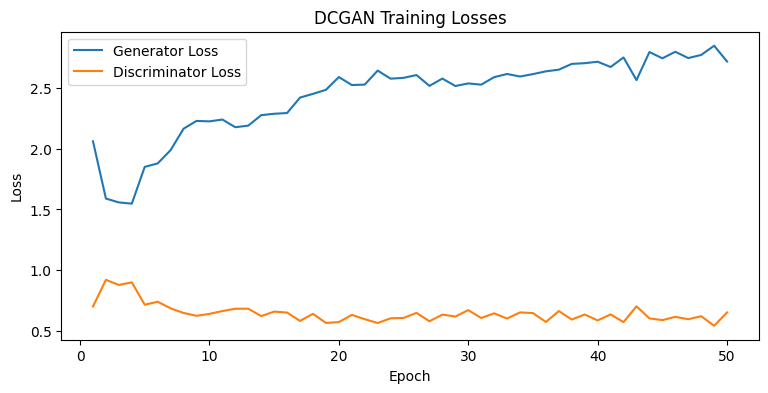

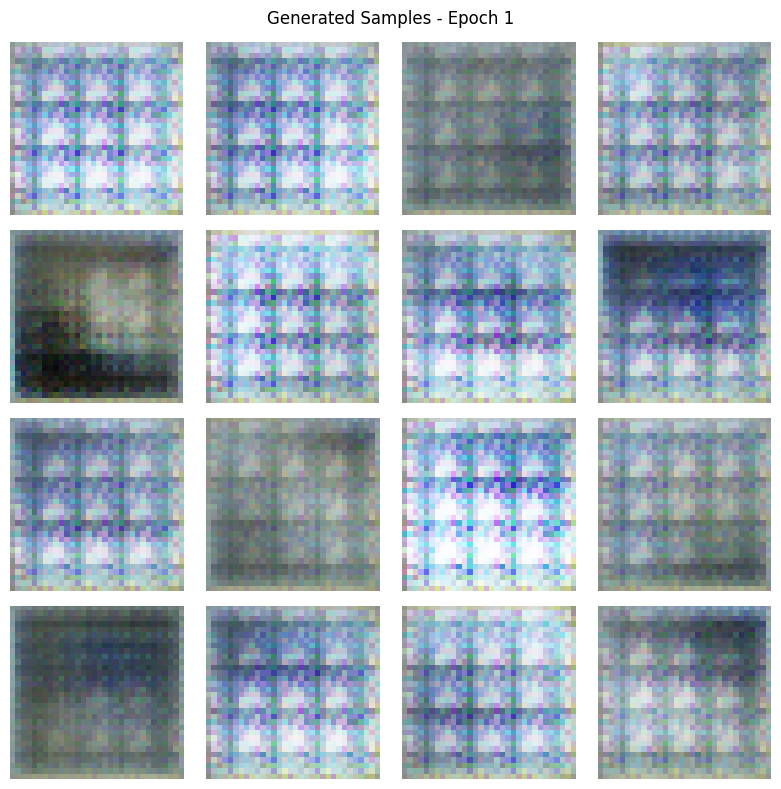

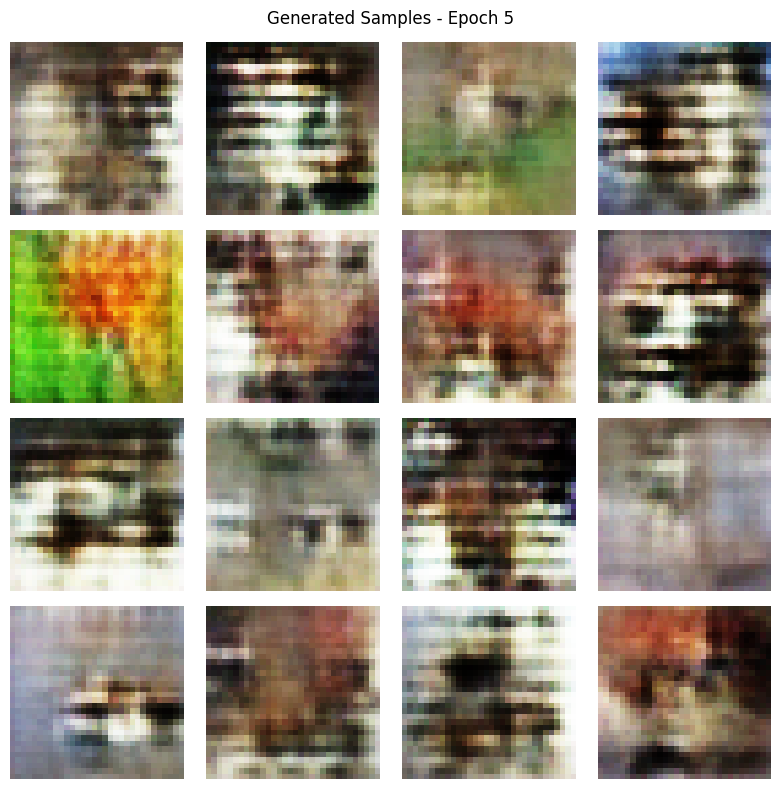

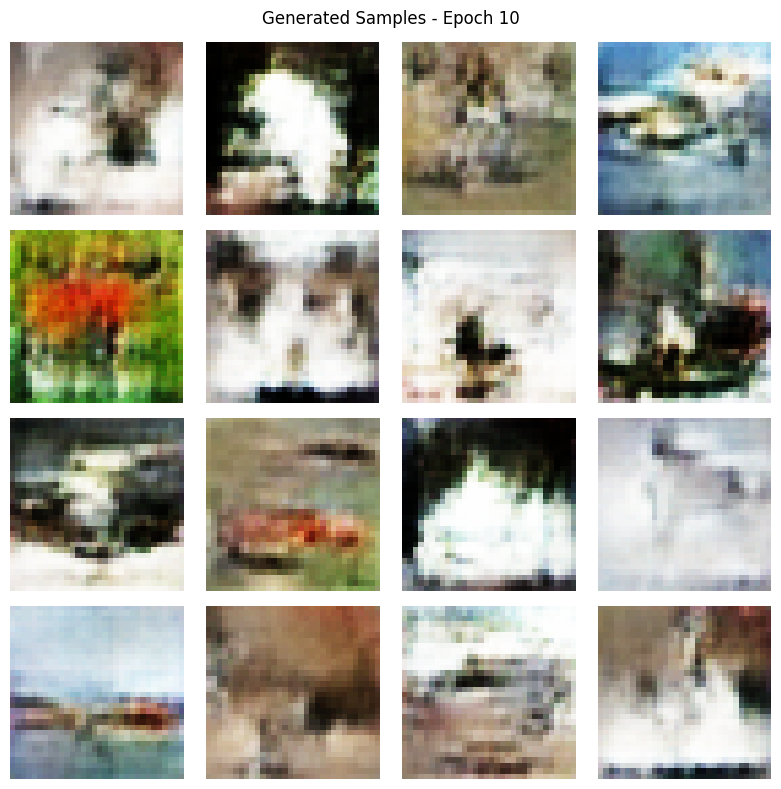

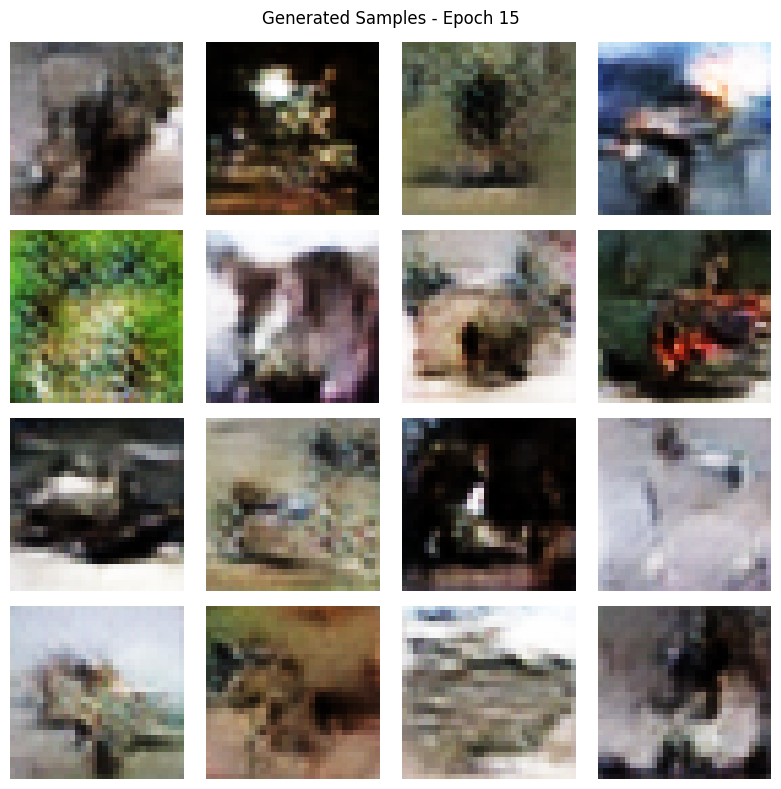

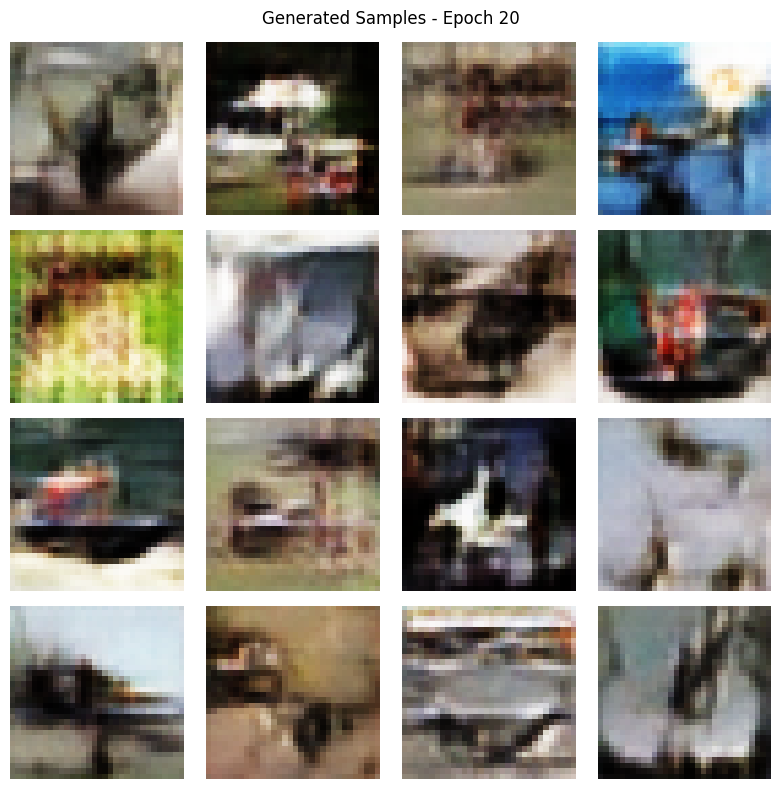

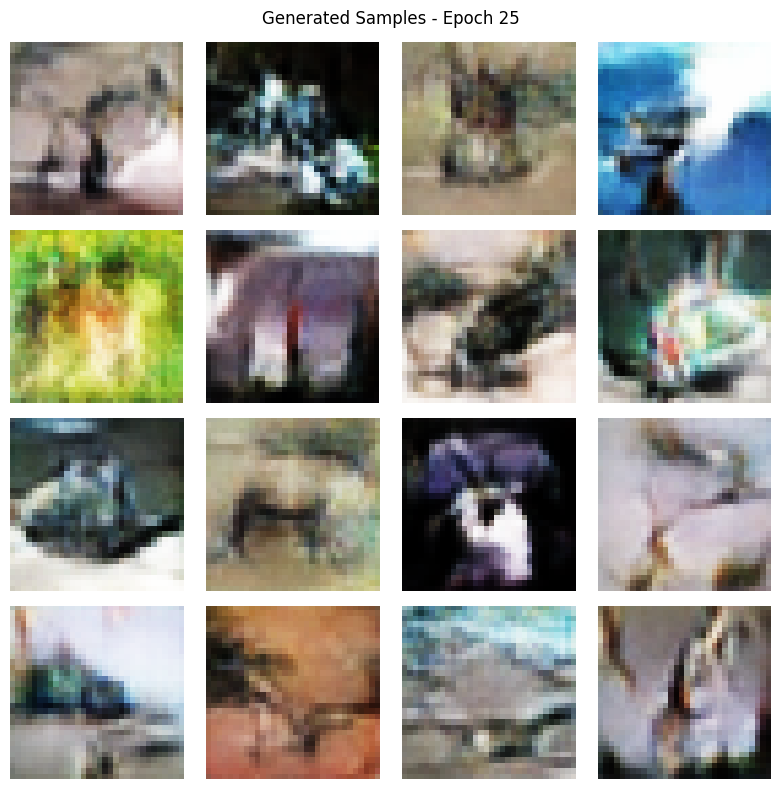

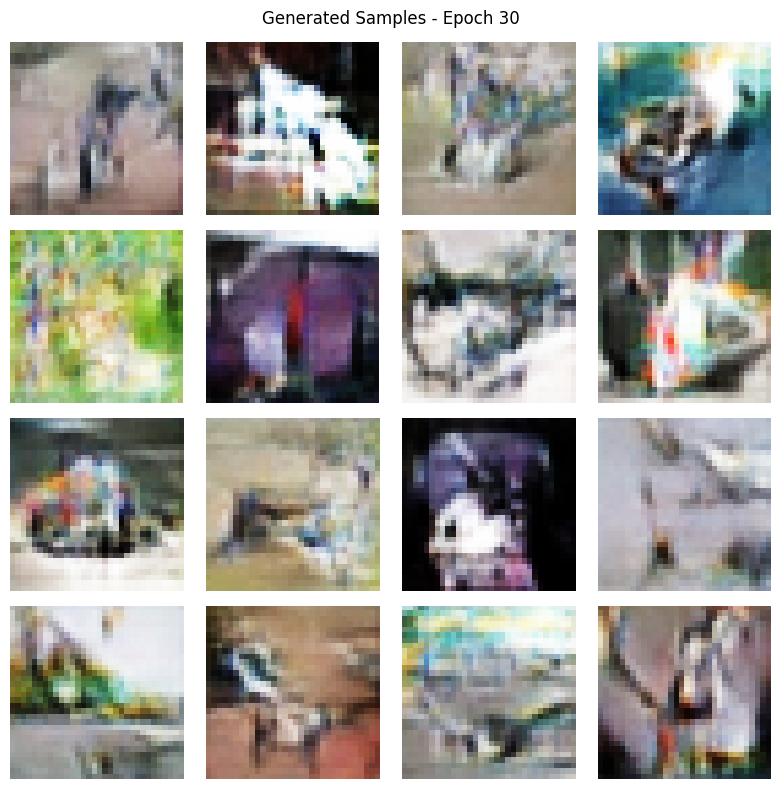

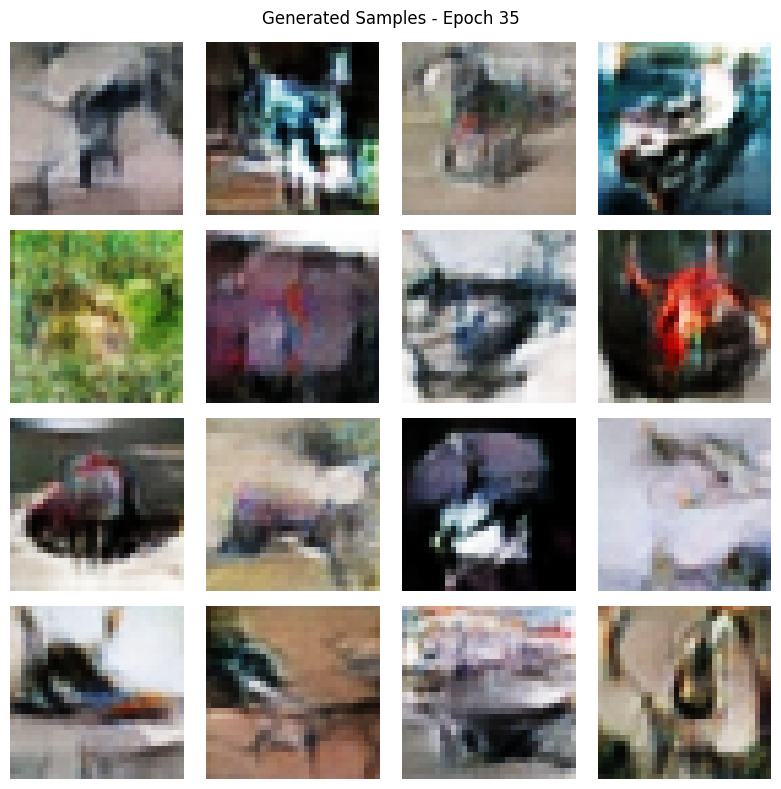

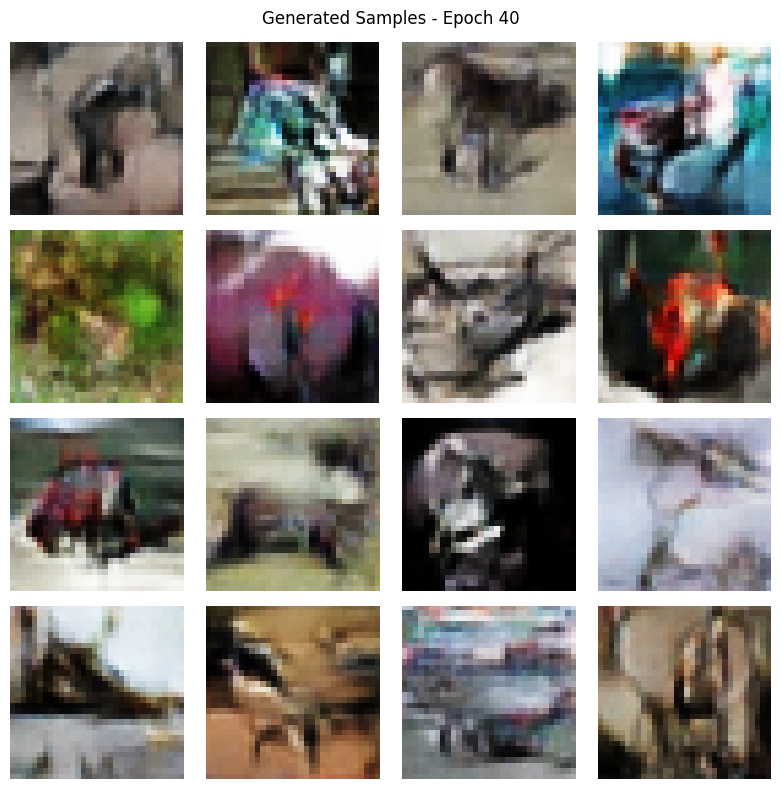

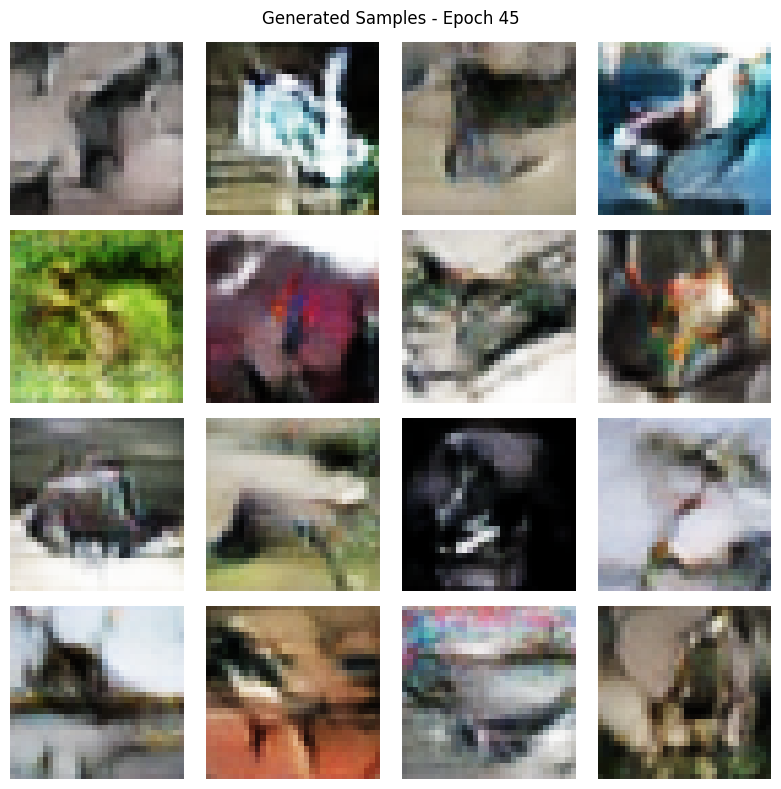

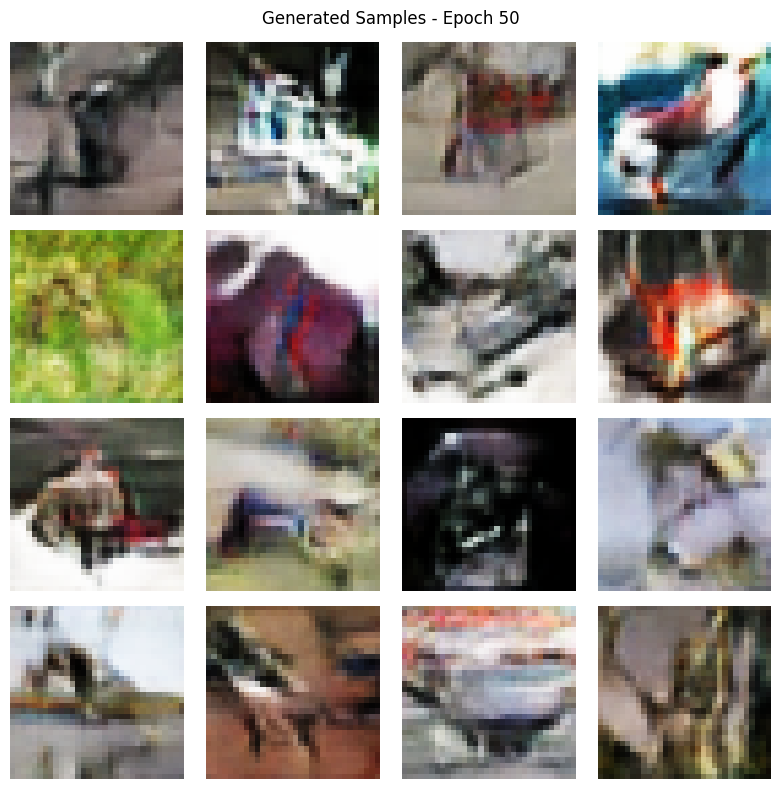

In [12]:
plt.figure(figsize=(9, 4))
plt.plot(
    range(1, EPOCHS + 1),
    generator_losses,
    label="Generator Loss"
)
plt.plot(
    range(1, EPOCHS + 1),
    discriminator_losses,
    label="Discriminator Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Training Losses")
plt.legend()
plt.show()

for epoch, images in zip(
    progress_epochs,
    progress_images
):
    plt.figure(figsize=(8, 8))

    for index in range(
        min(SAMPLE_COUNT, len(images))
    ):
        ax = plt.subplot(4, 4, index + 1)

        image = (
            images[index] * 127.5
            + 127.5
        )

        image = np.clip(
            image,
            0,
            255
        ).astype("uint8")

        plt.imshow(image)
        plt.axis("off")

    plt.suptitle(
        f"Generated Samples - Epoch {epoch}"
    )
    plt.tight_layout()
    plt.show()

## 13. Evaluate Final Generated Samples

Generate a larger final sample grid and inspect visual quality, diversity, and artifacts.

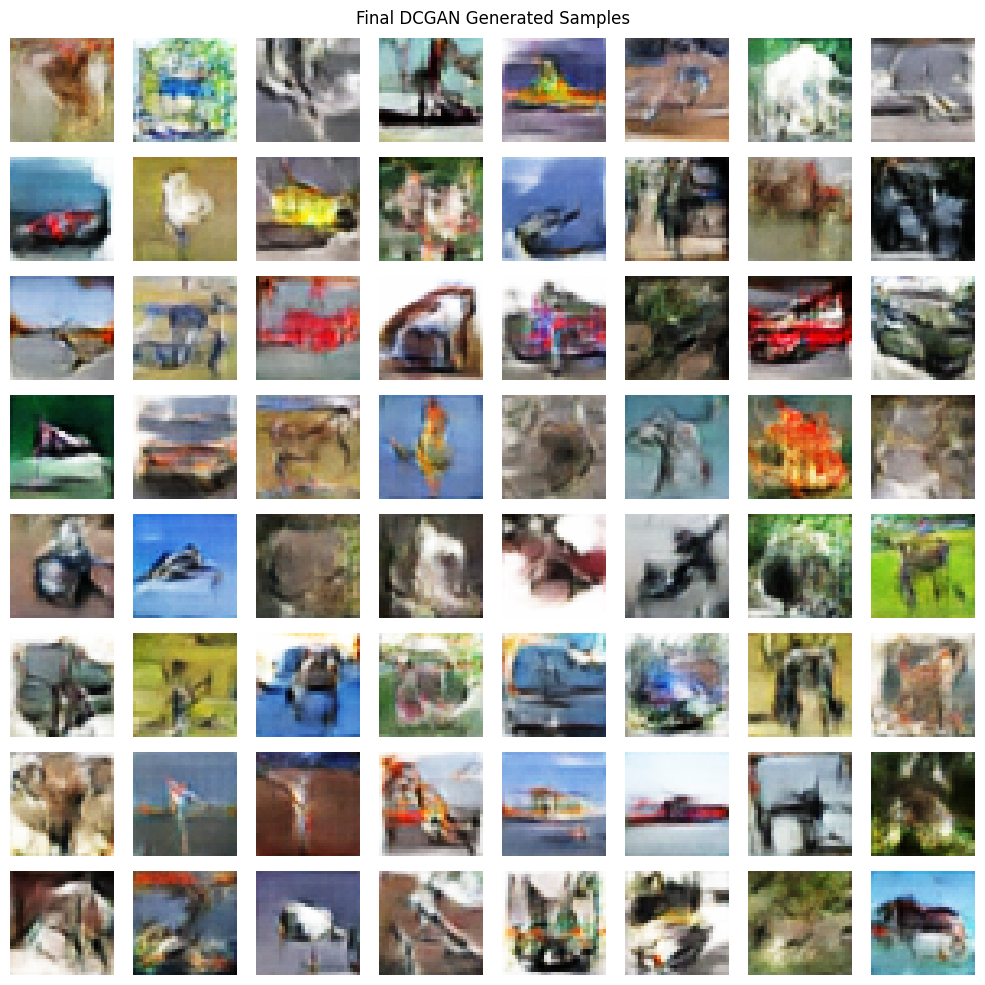

In [13]:
final_noise = tf.random.normal(
    [64, LATENT_DIM]
)

final_images = generator(
    final_noise,
    training=False
).numpy()

plt.figure(figsize=(10, 10))

for index in range(64):
    ax = plt.subplot(8, 8, index + 1)

    image = (
        final_images[index] * 127.5
        + 127.5
    )

    image = np.clip(
        image,
        0,
        255
    ).astype("uint8")

    plt.imshow(image)
    plt.axis("off")

plt.suptitle("Final DCGAN Generated Samples")
plt.tight_layout()
plt.show()

## 14. Latent Space Interpolation

Interpolate between latent vectors to examine whether the generator changes outputs smoothly.

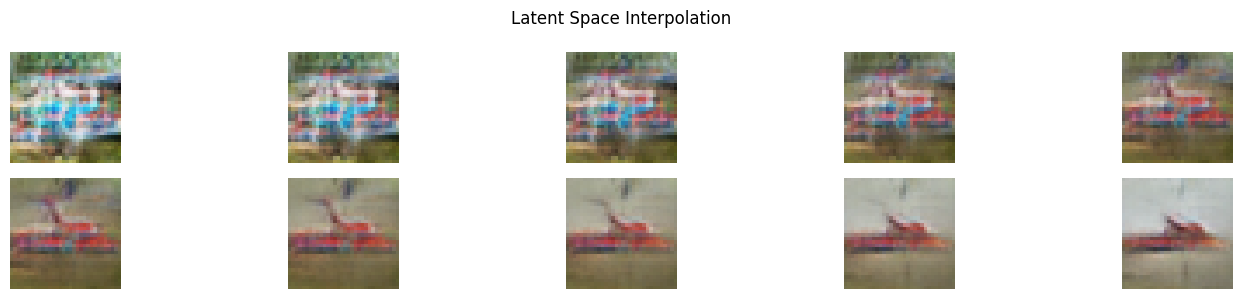

In [14]:
def interpolate_latent_vectors(
    vector_a,
    vector_b,
    steps=10
):
    alphas = np.linspace(
        0.0,
        1.0,
        steps
    )

    vectors = []

    for alpha in alphas:
        vectors.append(
            (1.0 - alpha) * vector_a
            + alpha * vector_b
        )

    return np.stack(vectors)

latent_a = tf.random.normal(
    [LATENT_DIM],
    seed=SEED + 1
)

latent_b = tf.random.normal(
    [LATENT_DIM],
    seed=SEED + 2
)

interpolated_vectors = interpolate_latent_vectors(
    latent_a.numpy(),
    latent_b.numpy(),
    steps=10
)

interpolated_images = generator(
    tf.convert_to_tensor(
        interpolated_vectors,
        dtype=tf.float32
    ),
    training=False
).numpy()

plt.figure(figsize=(15, 3))

for index, image in enumerate(
    interpolated_images
):
    ax = plt.subplot(2, 5, index + 1)

    image = (
        image * 127.5
        + 127.5
    )

    image = np.clip(
        image,
        0,
        255
    ).astype("uint8")

    plt.imshow(image)
    plt.axis("off")

plt.suptitle("Latent Space Interpolation")
plt.tight_layout()
plt.show()

## 15. Fixed-Noise Comparison

Use the same latent vectors to obtain a consistent final sample set for repeatable qualitative inspection.

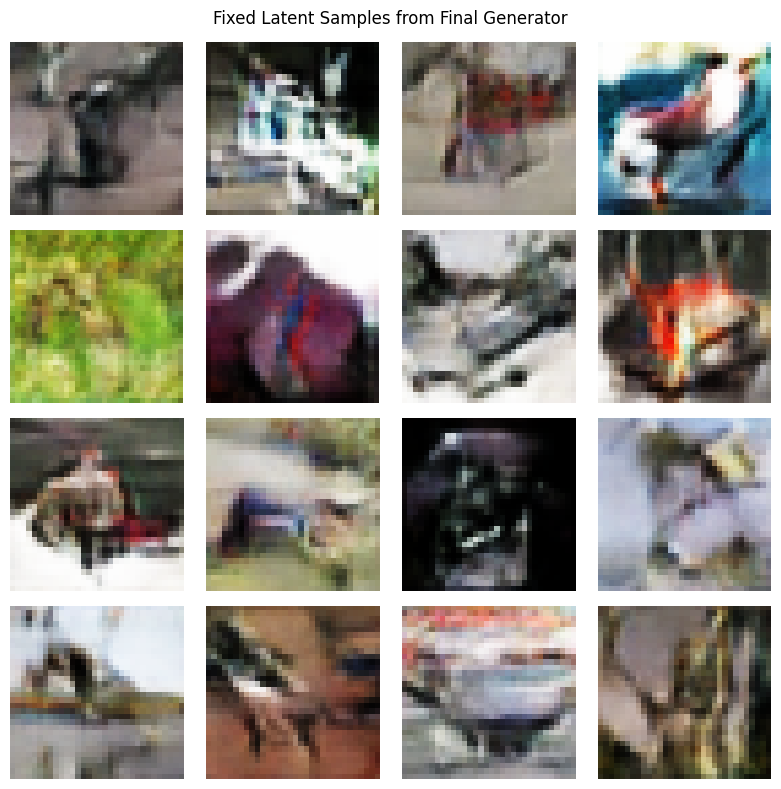

In [15]:
comparison_images = generator(
    fixed_noise,
    training=False
).numpy()

plt.figure(figsize=(8, 8))

for index in range(SAMPLE_COUNT):
    ax = plt.subplot(4, 4, index + 1)

    image = (
        comparison_images[index] * 127.5
        + 127.5
    )

    image = np.clip(
        image,
        0,
        255
    ).astype("uint8")

    plt.imshow(image)
    plt.axis("off")

plt.suptitle(
    "Fixed Latent Samples from Final Generator"
)
plt.tight_layout()
plt.show()

## 16. Training Findings

Summarize the observed adversarial dynamics and generated-image behaviour.

In [16]:
print(
    "Final Generator Loss:",
    generator_losses[-1]
)

print(
    "Final Discriminator Loss:",
    discriminator_losses[-1]
)

print(
    "Visual Checkpoints:",
    progress_epochs
)

print(
    "\nQualitative evaluation should focus on "
    "recognizability, diversity, artifacts, and "
    "possible mode collapse."
)

Final Generator Loss: 2.71761489090247
Final Discriminator Loss: 0.65279344305014
Visual Checkpoints: [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

Qualitative evaluation should focus on recognizability, diversity, artifacts, and possible mode collapse.


## 17. Conclusion

Summarize what the DCGAN experiment demonstrates and its main limitations.

In [17]:
print(
    "DCGAN training and evaluation are complete."
)

print(
    "The generator maps latent vectors to 32×32 RGB images."
)

print(
    "The discriminator learns to distinguish "
    "real CIFAR-10 images from generated samples."
)

DCGAN training and evaluation are complete.
The generator maps latent vectors to 32×32 RGB images.
The discriminator learns to distinguish real CIFAR-10 images from generated samples.
